# BUAD 5722 — Group 13 | Regression & Clustering

**OBJECTIVE**

 What socioeconomic factors predict state crime rates, and where are law-enforcement resources misaligned?


**Content**


1.   Import Libraries
2.   H2O Initialization & Feature Definition
3.   Train/Test split
4.   Run RF regression
5.   K-means (socioeconomic)






**Data sources:**
`state_crime_census_2022.csv`.

##Step 1 — Import Libraries

Libraries for data processing (pandas, numpy), visualization (matplotlib, seaborn, plotly), machine learning (sklearn, xgboost), and H2O have been imported.

 `warnings.filterwarnings(‘ignore’)` is used to keep the output clean by suppressing irrelevant warnings.

In [1]:
# Import all libraries used across all phases
import  time
import pandas as pd
import geopandas as gpd
import plotly
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn import preprocessing
from google.colab import drive
import xgboost as xgb

In [2]:
# Read the aggregated data from google drive
from google.colab import drive
drive.mount('/content/drive')

DRIVE_FOLDER = Path('/content/drive/Shareddrives/MSBA Group 13/Big Data /BUAD5722_Crime_Project')

df = pd.read_csv('/content/drive/Shareddrives/MSBA Group 13/Big Data /Final Project/BUAD5722_Crime_Project/state_crime_census_2022.csv')

sns.set_style("whitegrid")
sns.set_context("talk")


data = df.copy()
print(f"Raw shape: {data.shape}")
data.head()

Mounted at /content/drive
Raw shape: (51, 19)


,fips_state,total_incidents,total_offenses,total_victims,cleared_incidents,num_agencies,clearance_rate,NAME,median_household_income,unemployment_rate_pct,poverty_rate_pct,bachelors_degree_or_higher_pct,total_population,white_alone_pct,black_alone_pct,hispanic_latino_pct,housing_vacancy_rate_pct,state,crime_rate_per_100k
0,1,214804,214804,215483,214804,1,1.0,Alabama,59609,5.2,15.7,27.2,5028092,66.2,26.4,3.2,15.8,1,4272.08
1,2,14063,14063,14070,14063,1,1.0,Alaska,86370,6.4,10.5,30.7,734821,61.3,3.2,4.3,18.9,2,1913.80
2,4,189010,189010,189169,189010,1,1.0,Arizona,72581,5.4,13.1,31.8,7172282,66.7,4.6,17.4,11.6,4,2635.28
3,5,176545,176545,176630,176545,1,1.0,Arkansas,56335,5.1,16.2,24.7,3018669,72.7,15.1,6.6,14.6,5,5848.44
4,6,737745,737745,738210,737745,1,1.0,California,91905,6.4,12.1,35.9,39356104,48.1,5.6,25.7,7.7,6,1874.54


Output (51, 19) Explanation:

51 rows = 50 states + DC

19 columns = crime statistics variables + census socioeconomic variables

##Step2—H2O Initialization & Feature Definition:

Define 9 feature variables  
Target variable: crime_rate_per_100k

In [3]:
# YOUR CODE HERE — imports & h2o.init()
!pip install h2o
import h2o
from h2o.estimators.gbm import H2OGradientBoostingEstimator
from h2o.estimators.random_forest import H2ORandomForestEstimator
from h2o.automl import H2OAutoML
from h2o.grid.grid_search import H2OGridSearch

h2o.init()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.4/266.4 MB 5.7 MB/s eta 0:00:00
Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.18" 2026-01-20; OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1); OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp1a37y2w9
  JVM stdout: /tmp/tmp1a37y2w9/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmp1a37y2w9/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,05 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,"28 days, 3 hours and 49 minutes"
H2O_cluster_name:,H2O_from_python_unknownUser_f1tgbj
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [4]:
# ─Select columns for modeling ────────────────────────────────────
features = [
    'median_household_income',
    'unemployment_rate_pct',
    'poverty_rate_pct',
    'bachelors_degree_or_higher_pct',
    'total_population',
    'white_alone_pct',
    'black_alone_pct',
    'hispanic_latino_pct',
    'housing_vacancy_rate_pct'
]
target = 'crime_rate_per_100k'

# only keep select columns
model_df = data[features + [target, 'NAME']].copy()

# tansfor H2OFrame
hf = h2o.H2OFrame(model_df)
print(hf.shape)
hf.head()

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
(51, 11)


median_household_income,unemployment_rate_pct,poverty_rate_pct,bachelors_degree_or_higher_pct,total_population,white_alone_pct,black_alone_pct,hispanic_latino_pct,housing_vacancy_rate_pct,crime_rate_per_100k,NAME
59609,5.2,15.7,27.2,5.02809e+06,66.2,26.4,3.2,15.8,4272.08,Alabama
86370,6.4,10.5,30.7,734821,61.3,3.2,4.3,18.9,1913.8,Alaska
72581,5.4,13.1,31.8,7.17228e+06,66.7,4.6,17.4,11.6,2635.28,Arizona
56335,5.1,16.2,24.7,3.01867e+06,72.7,15.1,6.6,14.6,5848.44,Arkansas
91905,6.4,12.1,35.9,3.93561e+07,48.1,5.6,25.7,7.7,1874.54,California
87598,4.5,9.6,43.7,5.77079e+06,76.1,4,11.8,8.9,5677.66,Colorado
90213,5.9,10.1,41.4,3.61132e+06,69.8,10.7,11.3,7.9,3105.07,Connecticut
79325,5.4,11.1,34.5,993635,63.8,22,6.4,13.9,5307.88,Delaware
101722,7.1,15.1,62.6,670587,39.6,44.3,8.1,9.9,8906.53,District of Columbia
67917,5,12.9,32.3,2.16345e+07,63.8,15.5,14.8,15.8,984.55,Florida


### These nine socioeconomic variables serve as inputs, with the crime rate as the output; this is the core premise of the entire modeling process.

    'median_household_income',     

    'unemployment_rate_pct',        

    'poverty_rate_pct',            

    'bachelors_degree_or_higher_pct',

    'total_population',            

    'white_alone_pct',             

    'black_alone_pct',              

    'hispanic_latino_pct',          

    'housing_vacancy_rate_pct'      

predictor = 'crime_rate_per_100k'     


### Apply a log transformation to the target variable to mitigate the effects of a right-skewed distribution

In [5]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

# Apply a log transformation to the target variable to mitigate the effects of a right-skewed distribution
data['crime_rate_log'] = np.log(data['crime_rate_per_100k'])

# Redefine the target as the log-transformed crime rate
target_log = 'crime_rate_log'

model_df_log = data[features + [target_log, 'NAME']].copy()
hf_log = h2o.H2OFrame(model_df_log)


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


## Step3- Train/Test data Split（80/20）

In [8]:
# ── Train / Test Split（80/20）────────────────────────
train, test = hf_log.split_frame(ratios=[0.8], seed=42)
print(f"Train: {train.nrows} rows")   # 43
print(f"Test:  {test.nrows} rows")    # 8

Train: 43 rows
Test:  8 rows


## Step4-Regression Modeling (Random Forest)

RF (ntrees=50, depth=3, 5-fold CV)


In [9]:

# Initialize rf_log before training
rf_log = H2ORandomForestEstimator(
    ntrees=50,
    max_depth=3,
    nfolds=5,
    seed=42
)

rf_log.train(
    x=features,
    y=target_log,
    training_frame=train
)


print(f"CV RMSE: {rf_log.rmse(xval=True):.4f}")
print(f"CV R²:   {rf_log.r2(xval=True):.4f}")

# 在 test 上评估
perf = rf_log.model_performance(test_data=test)
print(f"Test RMSE: {perf.rmse():.4f}")
print(f"Test R²:   {perf.r2():.4f}")

drf Model Build progress: |██████████████████████████████████████████████████████| (done) 100%
CV RMSE: 0.4330
CV R²:   -0.0973
Test RMSE: 0.5333
Test R²:   0.1878


CV R² is calculated using 5-fold cross-validation on the 43 training samples, with each fold containing only about 34 data points in the training set and about 9 in the validation set. This results in extremely high variance, making negative values likely.

Test R² uses all 43 states for training and evaluates the model on the remaining 8 states. With a more comprehensive training dataset, the results are actually more stable.


The model yielded a positive R² value of 0.19, indicating that it possesses a certain degree of generalization ability.

### Feature Importance

                         variable  relative_importance  scaled_importance  \
0                total_population            49.424664           1.000000   
1        housing_vacancy_rate_pct            25.335938           0.512617   
2           unemployment_rate_pct            23.584312           0.477177   
3             hispanic_latino_pct            21.815599           0.441391   
4                poverty_rate_pct            15.317937           0.309925   
5         median_household_income             9.431115           0.190818   
6                 black_alone_pct             7.681485           0.155418   
7  bachelors_degree_or_higher_pct             7.328845           0.148283   
8                 white_alone_pct             7.021453           0.142064   

   percentage  
0    0.296060  
1    0.151766  
2    0.141273  
3    0.130678  
4    0.091756  
5    0.056494  
6    0.046013  
7    0.043901  
8    0.042059  


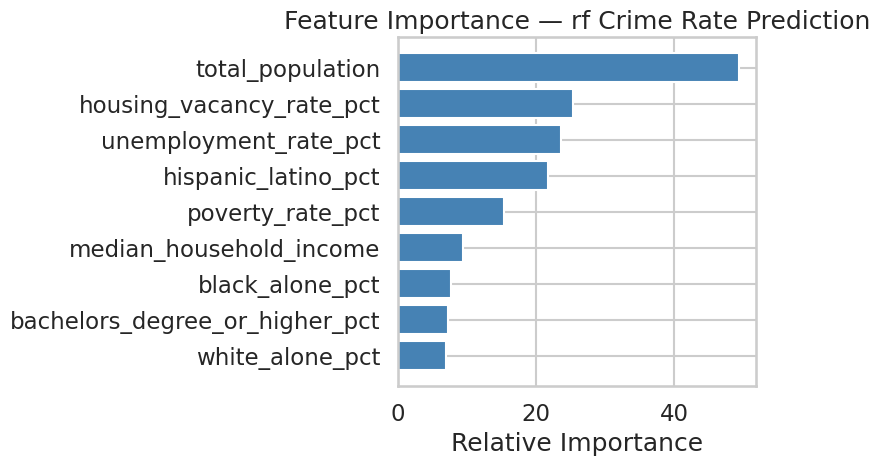

In [11]:
# ── Feature Importance ──────────────────────────────────────
importance = rf_log.varimp(use_pandas=True)
print(importance)

plt.figure(figsize=(8, 5))
plt.barh(importance['variable'], importance['relative_importance'], color='steelblue')
plt.xlabel('Relative Importance')
plt.title('Feature Importance — rf Crime Rate Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 1 Total Population (29.6%)
States with large populations tend to have systematically lower crime rates. Major cities generally have more robust law enforcement systems, social services, and infrastructure, and these structural advantages also help suppress crime rates.

### 2. Housing Vacancy Rate (15.2%)
The housing vacancy rate serves as a proxy indicator of community decline. A high vacancy rate signifies population loss, economic stagnation, and deteriorating infrastructure—all of which are structural conditions conducive to rising crime rates.

### 3. Unemployment Rate (14.1%)
Limited employment options → Increased economic pressure → Higher risk of crime

## Step5- K-Means Clustering: Where is resourse Misalignment Most Severe?

In [ ]:
# ── K-Means Clustering: Segmentation & Policy Implications ─────────────────
from h2o.estimators.kmeans import H2OKMeansEstimator
kmeans_model = H2OKMeansEstimator(
    k=4,
    seed=42,
    standardize=True
)

kmeans_model.train(
    x=features,
    training_frame=hf
)

print("=== K-Means result ===")
print(kmeans_model.centers_std())

kmeans Model Build progress: |███████████████████████████████████████████████████| (done) 100%
=== K-Means result ===
[[0.29595764405600516, 2.034016034620839, 0.30210538445267104, -1.0322243266277573], [-0.4269189548878409, 1.0314494566711916, 0.6570443158154571, 0.6102436732084898], [-0.5760649938479636, -0.058853747024890546, 0.2925925208104559, 1.2003823014353472], [0.19464538244531646, 2.757777589104429, 0.14121677873708552, -0.8653163677830076], [-0.26909034197967757, -0.41610241514218477, 2.8495757319992414, -0.15887839259589873], [0.34333455781900374, -1.8090704331564744, -0.9596822180932061, -0.2276072538359491], [-0.46090148136853115, 2.4953420749143964, 0.09339418543451765, 0.6374060736326862], [-0.17486028785817354, 0.06628488945345481, 1.8872401386399817, -0.16149010070453176], [-0.12416547163075395, -0.8035973573565435, -0.25517485705571263, 0.4626445545349502]]


K-Means does not use a target variable; instead, it automatically clusters the 51 states into 4 groups based solely on the similarity of 9 socioeconomic characteristics. Setting `standardize=True` is crucial; otherwise, variables with large scales (such as `total_population`, which is in the millions) will dominate the clustering results and overshadow the influence of other variables.

In [ ]:
# ── Reapply the clustering labels to the original data ──────────────────────────────
cluster_labels = kmeans_model.predict(hf).as_data_frame()
model_df['cluster'] = cluster_labels['predict'].values

# check each group's states
for c in sorted(model_df['cluster'].unique()):
    states = model_df[model_df['cluster'] == c]['NAME'].tolist()
    avg_crime = model_df[model_df['cluster'] == c][target].mean()
    print(f"\nCluster {c} (avg crime rate: {avg_crime:.1f}):")
    print(', '.join(states))

kmeans prediction progress: |████████████████████████████████████████████████████| (done) 100%

Cluster 0 (avg crime rate: 3675.3):
Alaska, Arizona, Colorado, Connecticut, Delaware, Hawaii, Idaho, Illinois, Indiana, Iowa, Kansas, Maine, Massachusetts, Minnesota, Missouri, Montana, Nebraska, New Hampshire, New Jersey, North Dakota, Ohio, Oregon, Pennsylvania, Rhode Island, South Dakota, Utah, Vermont, Virginia, Washington, Wisconsin, Wyoming

Cluster 1 (avg crime rate: 5995.9):
District of Columbia, Maryland

Cluster 2 (avg crime rate: 2193.1):
California, Florida, New York, Texas

Cluster 3 (avg crime rate: 4574.1):
Alabama, Arkansas, Georgia, Kentucky, Louisiana, Michigan, Mississippi, Nevada, New Mexico, North Carolina, Oklahoma, South Carolina, Tennessee, West Virginia


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


| Cluster | avg crime | state |
|:--------|:----------|:----------|
| Cluster 0 | 3675      | 32 states (primarily in the Midwest), the socioeconomic “Heartland,” with moderate populations and moderate crime rates |
| Cluster 1 | 5996 | DC and Maryland: extremely high levels of urbanization, high population density, and high levels of inequality |
| Cluster 2 | 2193 | CA, FL, NY, TX—megapopulation states—have abundant social resources but diluted crime statistics (low rates per 100,000) |
| Cluster 3 | 4574      | Primarily Southern states (AL, MS, LA, NM, etc.), with high poverty 、low education rate and high crime rates|

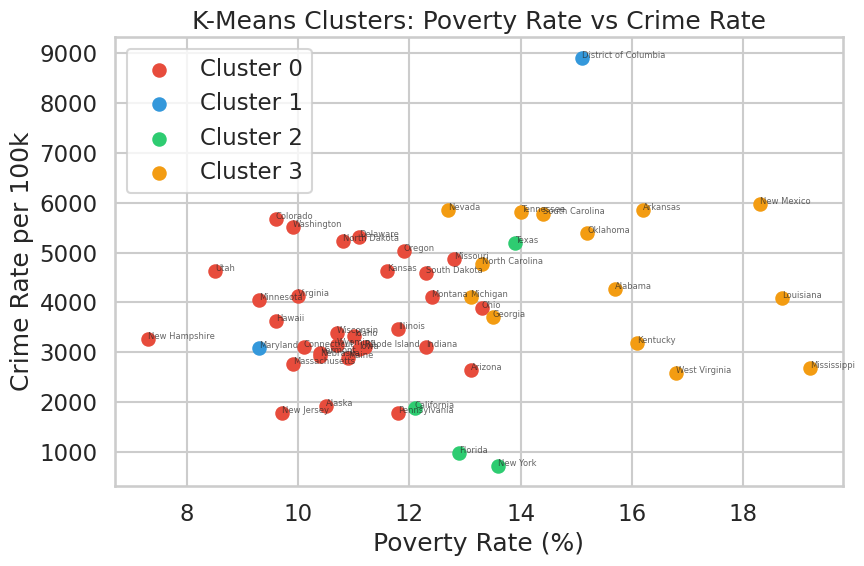

In [ ]:
# ── Visualization of Clustering Results (Poverty Rate vs. Crime Rate)────────────────
plt.figure(figsize=(9, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for c in sorted(model_df['cluster'].unique()):
    subset = model_df[model_df['cluster'] == c]
    plt.scatter(
        subset['poverty_rate_pct'],
        subset[target],
        label=f'Cluster {c}',
        color=colors[c],
        s=80
    )
    for _, row in subset.iterrows():
        plt.annotate(row['NAME'], (row['poverty_rate_pct'], row[target]),
                     fontsize=6, alpha=0.7)

plt.xlabel('Poverty Rate (%)')
plt.ylabel('Crime Rate per 100k')
plt.title('K-Means Clusters: Poverty Rate vs Crime Rate')
plt.legend()
plt.tight_layout()
plt.show()

Figure 2: K-Means Clustering Scatter Plot — Poverty Rate vs. Crime Rate

The x-axis represents the poverty rate, and the y-axis represents the crime rate per 100,000 people; the four colors correspond to the four clusters.

1. Cluster 0 (red, 32 states, the largest cluster) is distributed across the left and central regions of the graph, with poverty rates ranging from 7% to 13% and crime rates from 1,800 to 5,700. It covers most states in the Midwest and Northeast. This is the “socioeconomic middle ground,” characterized by significant internal variation but generally aligning with the national average.

2. Cluster 1 (blue, DC + Maryland): DC is the most conspicuous outlier in the chart—with a poverty rate of about 15% and a crime rate nearing 9,000, far exceeding all other states. As the nation’s capital, DC’s extremely high level of urbanization, severe wealth disparity, and unique administrative structure set it apart as a distinct category. Maryland lies adjacent to it, likely influenced by the DC metropolitan area. These two locations represent the most extreme cases of resource misallocation.

3. Cluster 2 (Green, CA / FL / NY / TX) Four states with extremely large populations form a cluster in the lower right corner of the chart—with poverty rates of 12%–14% (not low), but crime rates among the lowest in the nation (700–1,400). The real reason is that these large-population states (CA/NY/TX/FL) also have large urban populations with high incomes and high levels of education. These individuals raise the state’s overall education and income levels, and since education and income are the top three most important characteristics, this indirectly lowers crime rates.

4. Cluster 3 (orange, primarily Southern states) is concentrated on the right side of the chart, with poverty rates of 13%–19% and crime rates of 2,600–6,000, including New Mexico, Arkansas, Louisiana, Mississippi, and Alabama. This is the group with the strongest policy implications: high poverty rates combined with high crime rates, and these states generally allocate fewer resources to law enforcement and social services than the national average.

##**Note on DC:**
The District of Columbia is a city-state with no suburban or rural areas, making its crime_rate_per_100k structurally incomparable to the 50 states. It is retained in the dataset but flagged as an outlier.

Clustering results involving DC should be interpreted with this caveat.

In [ ]:
model_df = data[features + [target, 'NAME']].copy()

# delete DC
model_df = model_df[model_df['NAME'] != 'District of Columbia'].reset_index(drop=True)

print(f"Shape after removing DC: {model_df.shape}")  #  (50, 11)

Shape after removing DC: (50, 11)


In [ ]:
features = [
    'median_household_income',
    'unemployment_rate_pct',
    'poverty_rate_pct',
    'bachelors_degree_or_higher_pct',
    'total_population',
    'white_alone_pct',
    'black_alone_pct',
    'hispanic_latino_pct',
    'housing_vacancy_rate_pct'
]
target = 'crime_rate_per_100k'

model_df = data[features + [target, 'NAME']].copy()

# delete DC
dc_row = model_df[model_df['NAME'] == 'District of Columbia'].copy()  # 先保存备用
model_df = model_df[model_df['NAME'] != 'District of Columbia'].reset_index(drop=True)

print(f"Shape after removing DC: {model_df.shape}")  # (50, 11)
print(f"DC excluded — crime_rate: {dc_row[target].values[0]:.1f} (structural outlier, city-state)")

hf = h2o.H2OFrame(model_df)
print(hf.shape)
hf.head()

Shape after removing DC: (50, 11)
DC excluded — crime_rate: 8906.5 (structural outlier, city-state)
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
(50, 11)


median_household_income,unemployment_rate_pct,poverty_rate_pct,bachelors_degree_or_higher_pct,total_population,white_alone_pct,black_alone_pct,hispanic_latino_pct,housing_vacancy_rate_pct,crime_rate_per_100k,NAME
59609,5.2,15.7,27.2,5.02809e+06,66.2,26.4,3.2,15.8,4272.08,Alabama
86370,6.4,10.5,30.7,734821,61.3,3.2,4.3,18.9,1913.8,Alaska
72581,5.4,13.1,31.8,7.17228e+06,66.7,4.6,17.4,11.6,2635.28,Arizona
56335,5.1,16.2,24.7,3.01867e+06,72.7,15.1,6.6,14.6,5848.44,Arkansas
91905,6.4,12.1,35.9,3.93561e+07,48.1,5.6,25.7,7.7,1874.54,California
87598,4.5,9.6,43.7,5.77079e+06,76.1,4,11.8,8.9,5677.66,Colorado
90213,5.9,10.1,41.4,3.61132e+06,69.8,10.7,11.3,7.9,3105.07,Connecticut
79325,5.4,11.1,34.5,993635,63.8,22,6.4,13.9,5307.88,Delaware
67917,5,12.9,32.3,2.16345e+07,63.8,15.5,14.8,15.8,984.55,Florida
71355,5.2,13.5,33.6,1.07223e+07,54.3,31.5,6.7,10.8,3709.06,Georgia


In [ ]:
from h2o.estimators.kmeans import H2OKMeansEstimator

# k=3
kmeans_k3 = H2OKMeansEstimator(k=3, seed=42, standardize=True)
kmeans_k3.train(x=features, training_frame=hf)

print("=== K-Means k=3 (DC excluded) ===")
print(kmeans_k3.centers_std())

kmeans Model Build progress: |███████████████████████████████████████████████████| (done) 100%
=== K-Means k=3 (DC excluded) ===
[[0.40543630811631554, 0.3595625738104775, -1.0294437253545663], [-0.382945725934689, 0.7183400443628368, 0.6700645037470548], [-0.5741170133241672, 0.31380308802811796, 1.2226094338757811], [0.3910991456213288, 0.28348813077817014, -0.9749375130710859], [-0.2767923658379099, 2.8232602337259194, -0.17397751629218253], [0.2551743667338958, -1.0479180278960927, -0.28385054456430375], [-0.36286338375365856, 0.1746823582428286, 0.7794927747961252], [-0.1639439524068357, 1.8689136187038349, -0.1592462855569001], [-0.16288523975552768, -0.2650336104496718, 0.44803300814111024]]


In [ ]:
cluster_labels = kmeans_k3.predict(hf).as_data_frame()
model_df['cluster'] = cluster_labels['predict'].values

for c in sorted(model_df['cluster'].unique()):
    states = model_df[model_df['cluster'] == c]['NAME'].tolist()
    avg_crime = model_df[model_df['cluster'] == c][target].mean()
    print(f"\nCluster {c} (avg crime rate: {avg_crime:.1f}):")
    print(', '.join(states))

print("\n--- DC (excluded from clustering, shown for reference) ---")
print(f"DC crime_rate: {dc_row[target].values[0]:.1f}")

kmeans prediction progress: |████████████████████████████████████████████████████| (done) 100%

Cluster 0 (avg crime rate: 3656.9):
Alaska, Arizona, Colorado, Connecticut, Delaware, Hawaii, Idaho, Illinois, Indiana, Iowa, Kansas, Maine, Maryland, Massachusetts, Minnesota, Missouri, Montana, Nebraska, New Hampshire, New Jersey, North Dakota, Ohio, Oregon, Pennsylvania, Rhode Island, South Dakota, Utah, Vermont, Virginia, Washington, Wisconsin, Wyoming

Cluster 1 (avg crime rate: 2193.1):
California, Florida, New York, Texas

Cluster 2 (avg crime rate: 4574.1):
Alabama, Arkansas, Georgia, Kentucky, Louisiana, Michigan, Mississippi, Nevada, New Mexico, North Carolina, Oklahoma, South Carolina, Tennessee, West Virginia

--- DC (excluded from clustering, shown for reference) ---
DC crime_rate: 8906.5


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


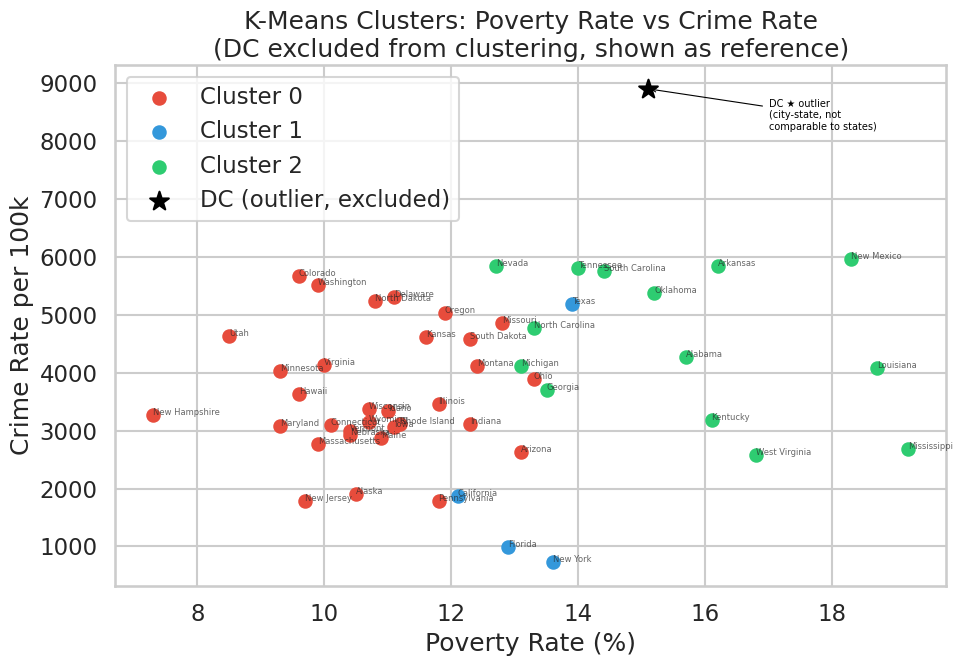

In [ ]:
plt.figure(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for c in sorted(model_df['cluster'].unique()):
    subset = model_df[model_df['cluster'] == c]
    plt.scatter(
        subset['poverty_rate_pct'],
        subset[target],
        label=f'Cluster {c}',
        color=colors[c],
        s=80
    )
    for _, row in subset.iterrows():
        plt.annotate(row['NAME'],
                     (row['poverty_rate_pct'], row[target]),
                     fontsize=6, alpha=0.7)

# Draw the DC separately and mark it with a black star
plt.scatter(
    dc_row['poverty_rate_pct'].values[0],
    dc_row[target].values[0],
    color='black', s=200, marker='*', zorder=5,
    label='DC (outlier, excluded)'
)
plt.annotate(
    'DC ★ outlier\n(city-state, not\ncomparable to states)',
    xy=(dc_row['poverty_rate_pct'].values[0], dc_row[target].values[0]),
    xytext=(17, 8200),
    fontsize=7,
    color='black',
    arrowprops=dict(arrowstyle='->', color='black', lw=0.8)
)

plt.xlabel('Poverty Rate (%)')
plt.ylabel('Crime Rate per 100k')
plt.title('K-Means Clusters: Poverty Rate vs Crime Rate\n(DC excluded from clustering, shown as reference)')
plt.legend()
plt.tight_layout()
plt.show()

## k=3 without DC

1. Cluster 0 (red, largest cluster) — Mainstream states
Occupying the left and central regions of the map, with poverty rates of 7%–13% and crime rates of 2,800–5,700. This cluster covers most states in the Midwest, Northeast, and West. It serves as the benchmark group for “moderate socioeconomic conditions and moderate crime rates”; while internal variations exist, it is the most representative overall.
2. Cluster 1 (Blue) — States with Large Populations and Low Crime Rates
California, Pennsylvania, Florida, New York, and Texas cluster together, with poverty rates of 12%–14% but the lowest crime rates in the nation (700–2,000). After k=3, this cluster becomes more distinct, and the conclusion of the “large-state paradox” becomes clearer: population size and the density of urban resources suppress crime rates, even when poverty rates are not low.
3. Cluster 2 (Green) — High-Risk Southern States
Concentrated on the right side of the map, with poverty rates of 14%–19% and crime rates of 2,600–6,000. This includes New Mexico, Arkansas, Tennessee, South Carolina, Alabama, Oklahoma, Louisiana, Mississippi, West Virginia, Kentucky, and others. High poverty combined with high crime rates indicates a systemic lack of investment in law enforcement and social resources.